In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde

from src.metrics.persuasiveness import Persuasiveness
from src.metrics.alignment import TFIDFAlignment, build_corpus

%load_ext autoreload
%autoreload 2

ROOT = Path('..')
BASE = ROOT / 'results' / 'mas' / 'databricks_full_run1'

W_VALUES  = [1, 2, 5]
W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
datasets  = ['gpqa', 'hiddenbench']

pers_metric = Persuasiveness()

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_window_data(w):
    folder = BASE / f'W{w}_fc'
    by_key = {}
    for f in sorted(folder.glob('*.json')):
        d = json.loads(f.read_text())
        qid = d['question_id']
        ds  = d.get('dataset', 'unknown')
        key = (ds, qid)
        if key not in by_key or str(f) > by_key[key]['_path']:
            d['_path'] = str(f)
            by_key[key] = d
    return by_key

raw = {w: load_window_data(w) for w in W_VALUES}
common_keys = sorted(set(raw[1].keys()) & set(raw[2].keys()) & set(raw[5].keys()))
print(f'Common (dataset, qid) pairs: {len(common_keys)}')

corpus = build_corpus(raw, common_keys)
tfidf_metric = TFIDFAlignment()
tfidf_metric.fit(corpus)
print(f'Corpus: {len(corpus)} messages — TF-IDF fitted.')

Common (dataset, qid) pairs: 30
Corpus: 107492 messages — TF-IDF fitted.


## Build agent-level records

One row per agent × repetition. Columns:
- `pers`: persuasiveness score for this agent in this repetition
- `tfidf_mean`: TF-IDF alignment for this repetition (rep-level, shared across agents)
- `prompt_tokens`, `completion_tokens`: summed over rounds for this agent
- `msg_chars`, `msg_words`: total characters / words across all messages this agent wrote

In [3]:
records = []

for w, data in raw.items():
    for (ds_key, qid), d in data.items():
        if (ds_key, qid) not in common_keys:
            continue
        for rep_idx, rep in enumerate(d['repetitions']):
            traj = rep['trajectory']
            T = len(traj)
            N = len(traj[0]['phase_b'])
            p_scores = pers_metric.score(rep)
            tfidf_score = tfidf_metric.score(rep)['mean']

            for a in range(N):
                prompt_toks = sum(
                    traj[t]['phase_b'][a].get('prompt_tokens', 0) for t in range(T)
                )
                completion_toks = sum(
                    traj[t]['phase_b'][a].get('completion_tokens', 0) for t in range(T)
                )
                msgs = [traj[t]['phase_b'][a].get('message', '') for t in range(T)]
                all_text = ' '.join(msgs)
                msg_chars = len(all_text)
                msg_words = len(all_text.split())

                records.append({
                    'W': w, 'qid': qid, 'dataset': ds_key,
                    'rep': rep_idx, 'agent': a,
                    'pers': p_scores[a],
                    'tfidf_mean': tfidf_score,
                    'prompt_tokens': prompt_toks,
                    'completion_tokens': completion_toks,
                    'msg_chars': msg_chars,
                    'msg_words': msg_words,
                })

df = pd.DataFrame(records)
print(f'Rows: {len(df)}  {df["dataset"].value_counts().to_dict()}')
print(df[['prompt_tokens','completion_tokens','msg_chars','msg_words','pers','tfidf_mean']].describe().round(1))

Rows: 18000  {'gpqa': 9000, 'hiddenbench': 9000}
       prompt_tokens  completion_tokens  msg_chars  msg_words     pers  \
count        18000.0            18000.0    18000.0    18000.0  18000.0   
mean         20392.4             1910.7     2793.2      426.8      0.2   
std          21701.9             1244.9     2612.4      399.8      0.5   
min           2676.0              493.0      248.0       36.0     -1.0   
25%           9167.5             1186.0     1331.0      203.0     -0.2   
50%          13562.5             1528.0     1961.0      298.0      0.0   
75%          21527.2             2111.2     3065.2      467.0      0.5   
max         166921.0            20669.0    24010.0     3638.0      1.0   

       tfidf_mean  
count     18000.0  
mean          0.5  
std           0.1  
min           0.2  
25%           0.4  
50%           0.5  
75%           0.5  
max           0.8  


---
## Plot 1 — Persuasiveness vs Token / Length Features

Each panel: x = token or length feature, y = Pers score.  
Left column = gpqa, right column = hiddenbench.  
Each point = one agent in one repetition (scatter + binned mean ± 95% CI overlay).  
Three features: prompt tokens, completion tokens, message character count (sanity check).

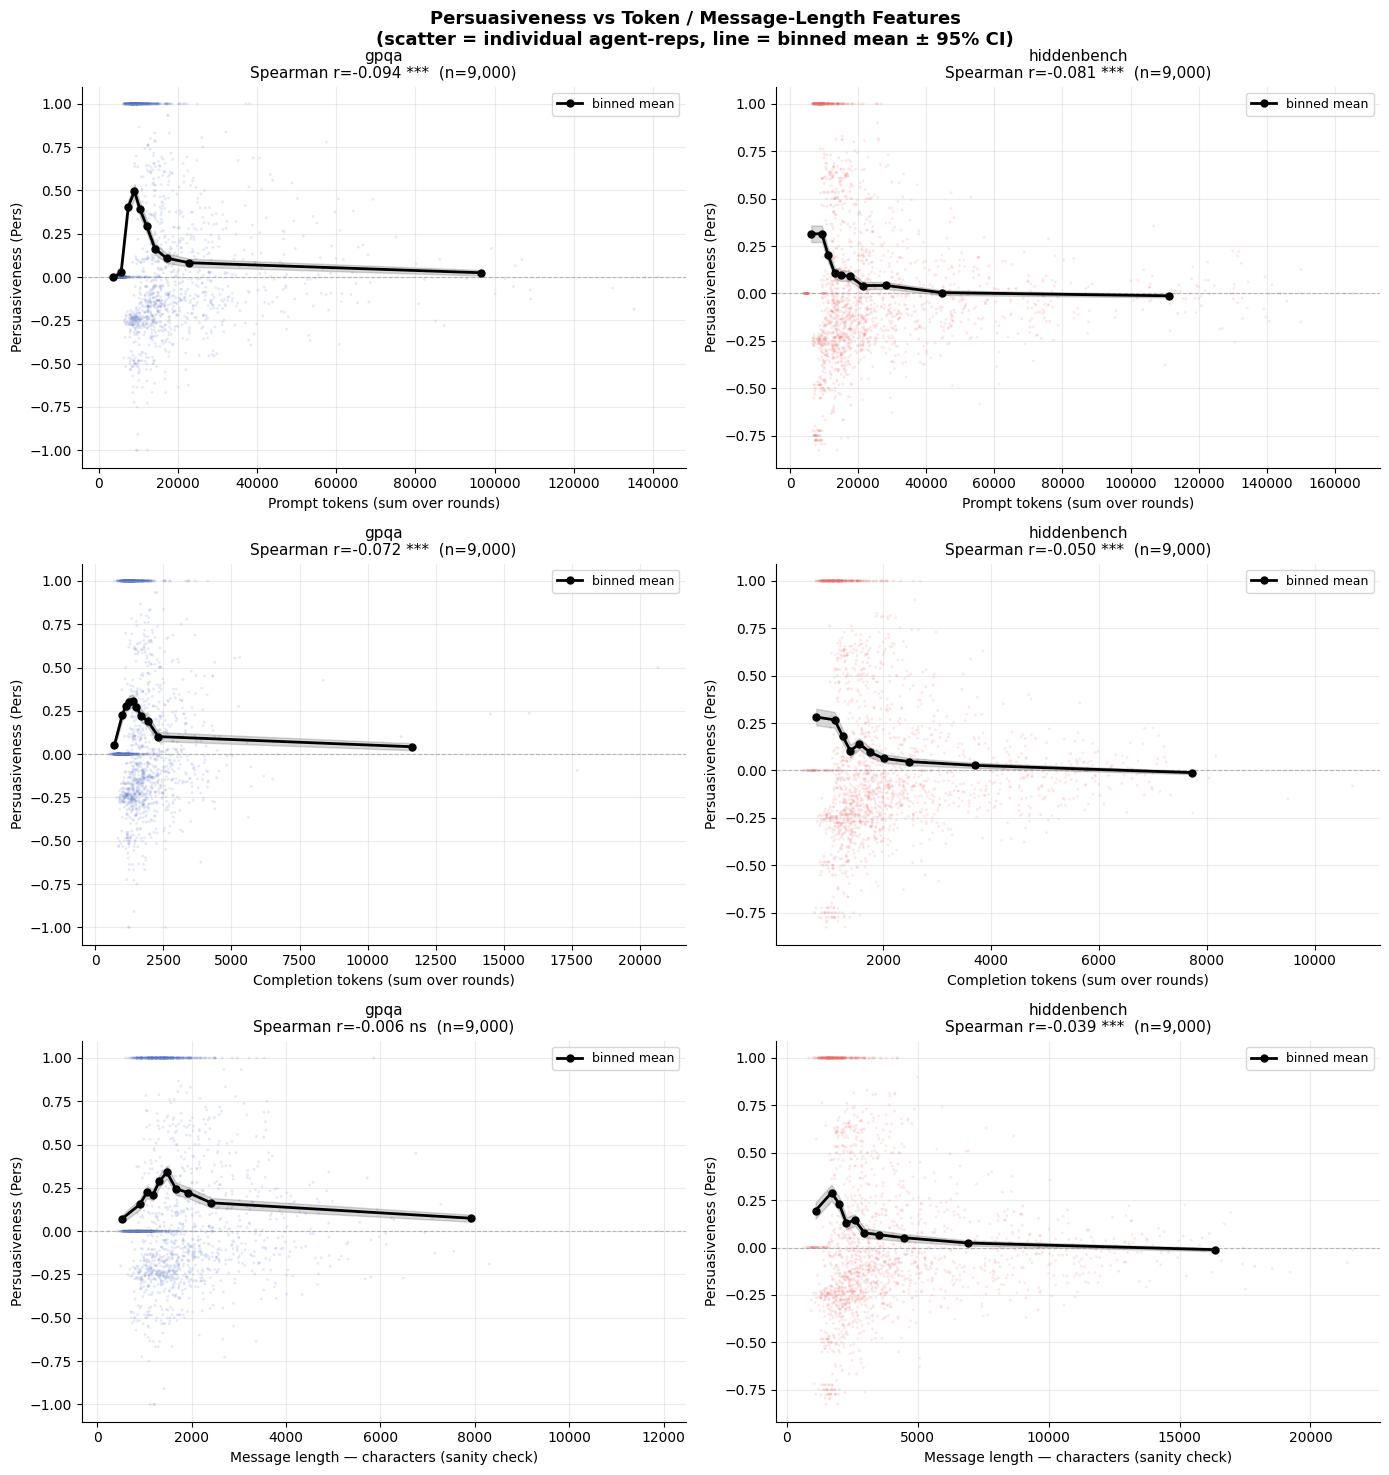

In [4]:
features = [
    ('prompt_tokens',     'Prompt tokens (sum over rounds)'),
    ('completion_tokens', 'Completion tokens (sum over rounds)'),
    ('msg_chars',         'Message length — characters (sanity check)'),
]

fig, axes = plt.subplots(len(features), 2, figsize=(14, 5 * len(features)))

for row, (feat, flabel) in enumerate(features):
    for col, ds in enumerate(datasets):
        ax = axes[row, col]
        sub = df[df['dataset'] == ds].copy()
        color = DS_COLORS[ds]

        # scatter (sample to keep readable)
        sample = sub.sample(min(2000, len(sub)), random_state=42)
        ax.scatter(sample[feat], sample['pers'],
                   color=color, s=4, alpha=0.15, edgecolors='none')

        # binned mean ± 95% CI
        bins = np.percentile(sub[feat], np.linspace(0, 100, 11))
        bins = np.unique(bins)
        if len(bins) >= 3:
            lbls = (bins[:-1] + bins[1:]) / 2
            cut  = pd.cut(sub[feat], bins=bins, labels=lbls)
            grp  = sub.groupby(cut, observed=False)['pers']
            means, sems, ns = grp.mean(), grp.sem(), grp.count()
            valid = ns >= 5
            xs = means.index.astype(float)[valid]
            ax.plot(xs, means[valid], color='black', linewidth=2,
                    marker='o', markersize=5, zorder=5, label='binned mean')
            ax.fill_between(xs,
                            (means - sems * 1.96)[valid],
                            (means + sems * 1.96)[valid],
                            color='black', alpha=0.15)

        r, p = sp_stats.spearmanr(sub[feat], sub['pers'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_xlabel(flabel, fontsize=10)
        ax.set_ylabel('Persuasiveness (Pers)', fontsize=10)
        ax.set_title(f'{ds}\nSpearman r={r:.3f} {sig}  (n={len(sub):,})', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig.suptitle('Persuasiveness vs Token / Message-Length Features\n'
             '(scatter = individual agent-reps, line = binned mean ± 95% CI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Plot 2 — Alignment vs Token / Length Features

Same layout as Plot 1 but y-axis = TF-IDF alignment (rep-level score, same value for all agents in that rep).  
Aggregated to rep level first (one dot per repetition) to avoid pseudo-replication.

Rep-level rows: 4500  {'gpqa': 2250, 'hiddenbench': 2250}


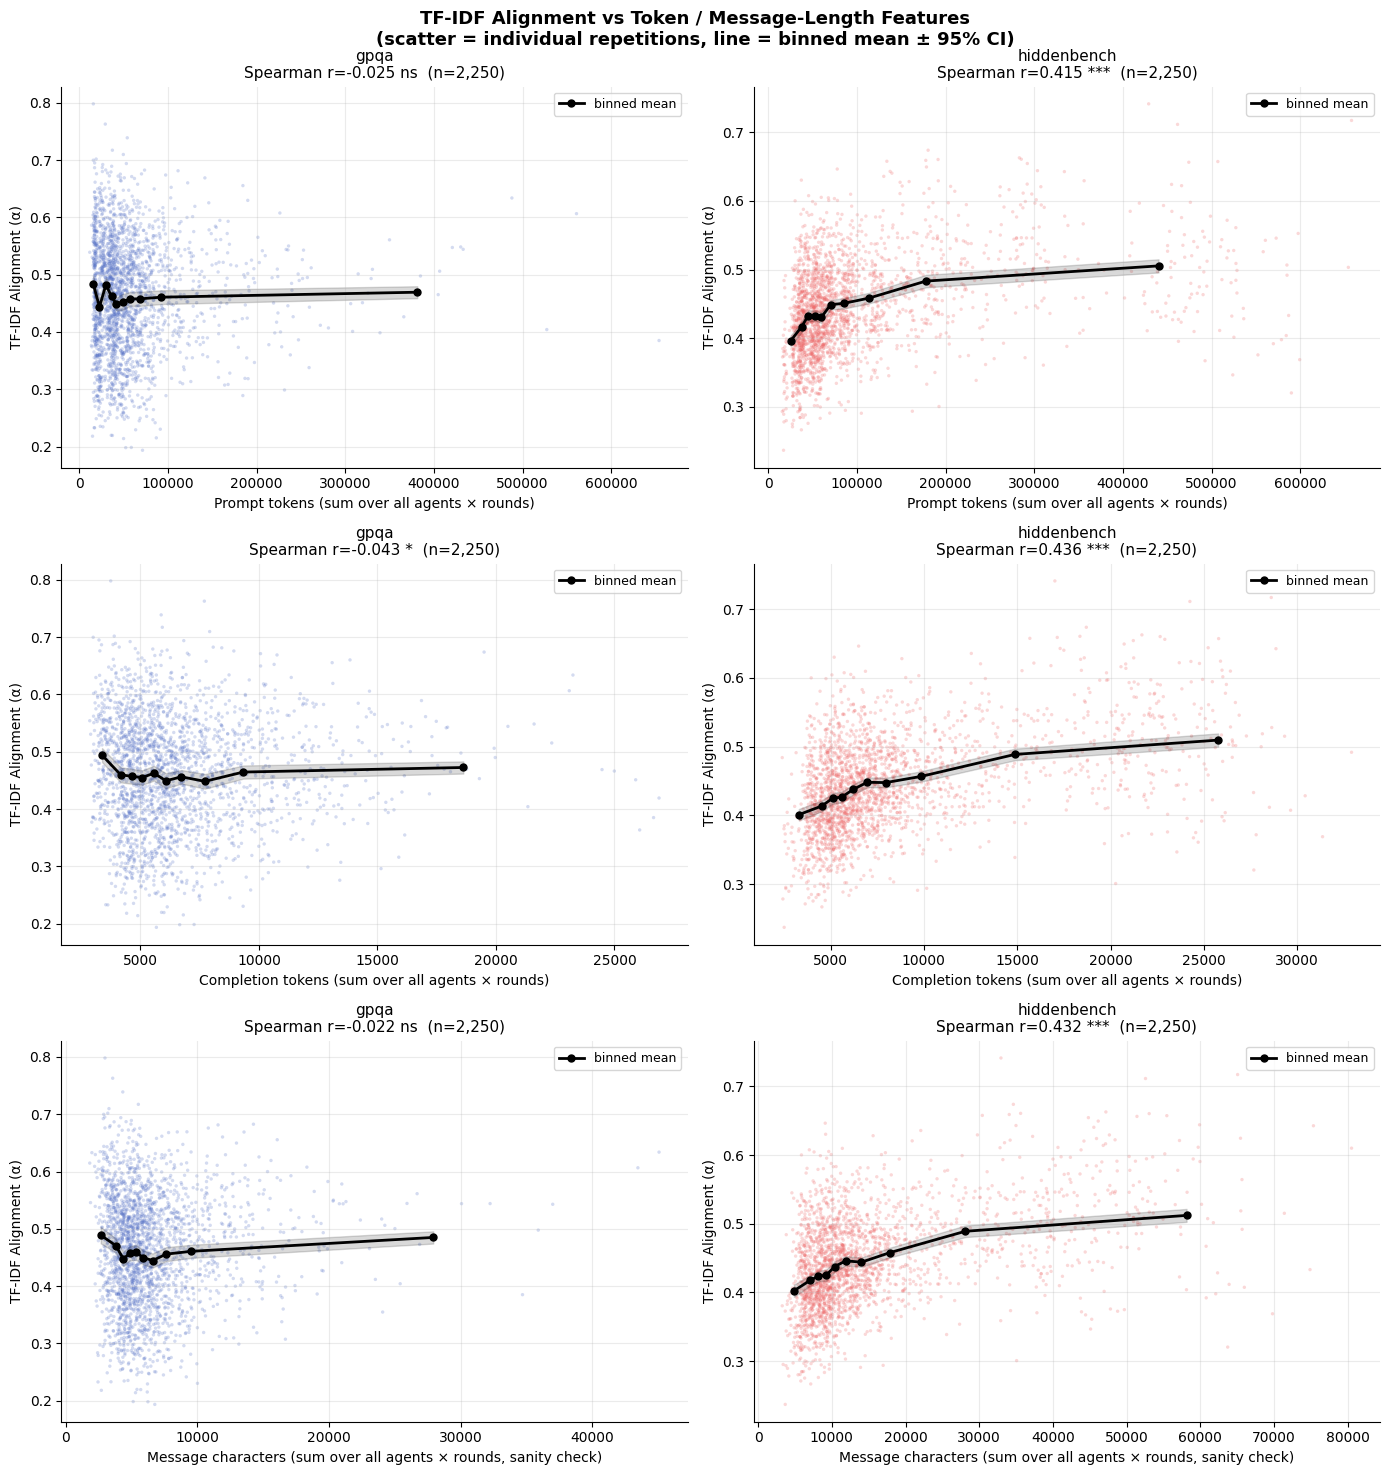

In [5]:
# aggregate to rep level: sum tokens / chars across agents within a rep
rep_df = df.groupby(['dataset', 'W', 'qid', 'rep']).agg(
    tfidf_mean=('tfidf_mean', 'first'),
    prompt_tokens=('prompt_tokens', 'sum'),
    completion_tokens=('completion_tokens', 'sum'),
    msg_chars=('msg_chars', 'sum'),
    msg_words=('msg_words', 'sum'),
).reset_index()

print(f'Rep-level rows: {len(rep_df)}  {rep_df["dataset"].value_counts().to_dict()}')

rep_features = [
    ('prompt_tokens',     'Prompt tokens (sum over all agents × rounds)'),
    ('completion_tokens', 'Completion tokens (sum over all agents × rounds)'),
    ('msg_chars',         'Message characters (sum over all agents × rounds, sanity check)'),
]

fig, axes = plt.subplots(len(rep_features), 2, figsize=(14, 5 * len(rep_features)))

for row, (feat, flabel) in enumerate(rep_features):
    for col, ds in enumerate(datasets):
        ax = axes[row, col]
        sub = rep_df[rep_df['dataset'] == ds].copy()
        color = DS_COLORS[ds]

        # scatter
        ax.scatter(sub[feat], sub['tfidf_mean'],
                   color=color, s=6, alpha=0.25, edgecolors='none')

        # binned mean ± 95% CI
        bins = np.percentile(sub[feat], np.linspace(0, 100, 11))
        bins = np.unique(bins)
        if len(bins) >= 3:
            lbls = (bins[:-1] + bins[1:]) / 2
            cut  = pd.cut(sub[feat], bins=bins, labels=lbls)
            grp  = sub.groupby(cut, observed=False)['tfidf_mean']
            means, sems, ns = grp.mean(), grp.sem(), grp.count()
            valid = ns >= 5
            xs = means.index.astype(float)[valid]
            ax.plot(xs, means[valid], color='black', linewidth=2,
                    marker='o', markersize=5, zorder=5, label='binned mean')
            ax.fill_between(xs,
                            (means - sems * 1.96)[valid],
                            (means + sems * 1.96)[valid],
                            color='black', alpha=0.15)

        r, p = sp_stats.spearmanr(sub[feat], sub['tfidf_mean'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.set_xlabel(flabel, fontsize=10)
        ax.set_ylabel('TF-IDF Alignment (α)', fontsize=10)
        ax.set_title(f'{ds}\nSpearman r={r:.3f} {sig}  (n={len(sub):,})', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig.suptitle('TF-IDF Alignment vs Token / Message-Length Features\n'
             '(scatter = individual repetitions, line = binned mean ± 95% CI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()